# 5º Projeto - Sistemas inteligentes
Autores: <br>
Alex Bruno Duarte <br>
Guilherme de França Vasconcelos

In [ ]:
# Importando as bibliotecas básicas
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, f1_score, recall_score, precision_score
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. Processamento dos dados

In [ ]:
col_names = [
"duration", "protocol_type", "service", "flag", "src_bytes",
"dst_bytes", "land", "wrong_fragment", "urgent", "hot",
"num_failed_logins", "logged_in", "num_compromised", "root_shell",
"su_attempted", "num_root", "num_file_creations", "num_shells",
"num_access_files", "num_outbound_cmds", "is_host_login",
"is_guest_login", "count", "srv_count", "serror_rate",
"srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
"diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
"dst_host_srv_count", "dst_host_same_srv_rate",
"dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
"dst_host_srv_diff_host_rate", "dst_host_serror_rate",
"dst_host_srv_serror_rate", "dst_host_rerror_rate",
"dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

def processar(url, is_train=True):
    df = pd.read_csv(url, names=col_names, sep=",")

    # Descartar a coluna difficulty_level
    df = df.drop('difficulty_level', axis=1)

    # Binarizar o rótulo (normal -> 0; qualquer ataque -> 1)
    df['attack_type'] = df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

    return df

train_df = processar('https://raw.githubusercontent.com/guilhermef2k/Sistemas_Inteligentes/refs/heads/main/MLP/dataset/KDDTrain%2B.txt')
test_df = processar('https://raw.githubusercontent.com/guilhermef2k/Sistemas_Inteligentes/refs/heads/main/MLP/dataset/KDDTest%2B.txt')
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0


In [ ]:
# separação em X e y
y_train_full = train_df['attack_type'].values
X_train_full = train_df.drop('attack_type', axis=1)

y_test = test_df['attack_type'].values
X_test = test_df.drop('attack_type', axis=1)

In [ ]:
# ONE-HOT ENCODING
X_combined = pd.concat([X_train_full, X_test])
X_combined = pd.get_dummies(X_combined, columns=['protocol_type', 'service', 'flag'])

X_train_full = X_combined.iloc[:len(train_df)]
X_test = X_combined.iloc[len(train_df):]

In [ ]:
# SPLIT E NORMALIZAÇÃO
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, shuffle=False
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## 2. Implementação da MLP em PyTorch

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)

X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1).to(device)

X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(device)
peso = torch.tensor([20]).to(device)

In [ ]:
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 100)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(100, 50)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(50, 25)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(25, 1)
        # self.relu4 = nn.ReLU()
        # self.fc5 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        # x = self.relu4(self.fc4(x))
        # x = self.fc3(x)
        x = self.fc4(x)
        return x

In [ ]:
print(X_train.shape[1])
model = MLP(X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=peso)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

122


## 3. Treinamento e monitoramento

In [ ]:
epochs = 50
train_losses = []
val_losses = []

# Variáveis para Early Stopping simples
best_val_loss = float('inf')
patience = 15
patience_counter = 0
best_model_state = None

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    avg_train_loss = np.mean(batch_losses)
    train_losses.append(avg_train_loss)

    # Validação
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t).item()
        val_losses.append(val_loss)

    print(f"Época {epoch+1}/{epochs} | Treino Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping acionado na época {epoch+1}!")
            break

# Restaurar os melhores pesos encontrados na validação
model.load_state_dict(best_model_state)

Época 1/50 | Treino Loss: 0.7923 | Val Loss: 0.1676
Época 2/50 | Treino Loss: 0.1569 | Val Loss: 0.1075
Época 3/50 | Treino Loss: 0.1245 | Val Loss: 0.0995
Época 4/50 | Treino Loss: 0.1091 | Val Loss: 0.0868
Época 5/50 | Treino Loss: 0.0999 | Val Loss: 0.0857
Época 6/50 | Treino Loss: 0.1010 | Val Loss: 0.0844
Época 7/50 | Treino Loss: 0.0921 | Val Loss: 0.0754
Época 8/50 | Treino Loss: 0.0869 | Val Loss: 0.0787
Época 9/50 | Treino Loss: 0.0864 | Val Loss: 0.0755
Época 10/50 | Treino Loss: 0.0816 | Val Loss: 0.0841
Época 11/50 | Treino Loss: 0.0806 | Val Loss: 0.0691
Época 12/50 | Treino Loss: 0.0798 | Val Loss: 0.0656
Época 13/50 | Treino Loss: 0.0757 | Val Loss: 0.0601
Época 14/50 | Treino Loss: 0.0738 | Val Loss: 0.0614
Época 15/50 | Treino Loss: 0.0746 | Val Loss: 0.0640
Época 16/50 | Treino Loss: 0.0725 | Val Loss: 0.0710
Época 17/50 | Treino Loss: 0.0721 | Val Loss: 0.0598
Época 18/50 | Treino Loss: 0.0682 | Val Loss: 0.0553
Época 19/50 | Treino Loss: 0.0679 | Val Loss: 0.0559
Ép

<All keys matched successfully>

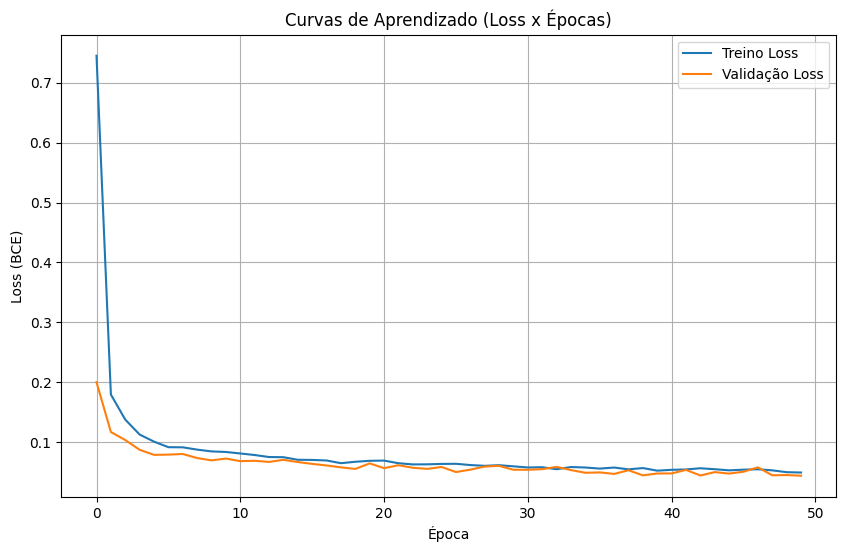

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Treino Loss')
plt.plot(val_losses, label='Validação Loss')
plt.title('Curvas de Aprendizado (Loss x Épocas)')
plt.xlabel('Época')
plt.ylabel('Loss (BCE)')
plt.legend()
plt.grid(True)
plt.show()

## 4. Avaliação final


--- AVALIAÇÃO NO CONJUNTO DE TESTE ---
Acurácia: 0.8478
Precisão: 0.9247
Recall:   0.7976
F1-Score: 0.8564


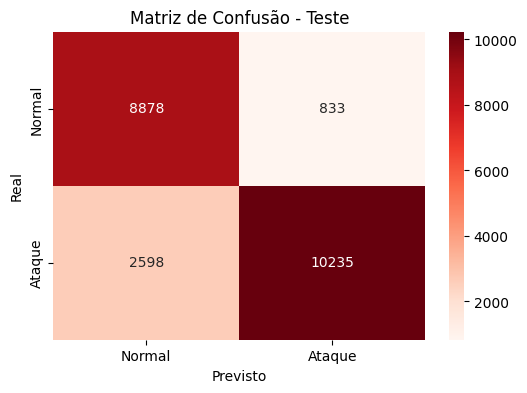

In [ ]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    # Aplicando sigmoide para transformar logits em probabilidades
    probs = torch.sigmoid(test_outputs).cpu().numpy()

# Limiar de 0.5
y_pred = (probs >= 0.5).astype(int)

print("\n--- AVALIAÇÃO NO CONJUNTO DE TESTE ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Normal', 'Ataque'], yticklabels=['Normal', 'Ataque'])
plt.title('Matriz de Confusão - Teste')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

Em um sistema de detecção de intrusão em produção, um falso negativo (um ataque classificado como conexão normal) é consideravelmente mais crítico do que um Falso Positivo. Se o sistema não detecta um ataque, a rede pode ser comprometida resultando em vazamento de dados, perdas financeiras e paralização do sistema como um todo. Já se o sistema detectar uma conexão normal como ataque, a perda será apenas o tempo gasto pela equipe de segurança para averiguar o alerta.

Como os falsos negativos oferecem maior risco, a métrica priorizada deve ser o recall. No código padrão, o limiar que define a separação entre as classes após a ativação sigmoide é de 0.5. Ao abaixar esse limiar, o modelo torna-se mais sensível a ameaças, assumindo que algo é um ataque mesmo com uma probabilidade menor de certeza. Isso aumenta a taxa de detecção de ataques genuínos (reduzindo os Falsos Negativos) e aumenta a segurança da rede, às custas de gerar mais alertas falsos (aumento dos Falsos Positivos).

## Conclusão

Por meio da análise dos resultados, conclui-se que o modelo em questão não é indicado para integrar um sistema de detecção de intrusão. O número alto de falsos-negativos (próximo de 3000) colocaria o sistema monitorado em risco. O conjunto de teste utilizado provavelmente possui novos tipos de ataque que não estão presentes no conjunto de treinamento. Portanto, para um melhor desempenho nesse problema seria necessário o uso de algoritmos e técnicas avançadas com alto poder de generalização.